Training finished.
Final epsilon = 0.05
Success rate over last 100 episodes = 0.0


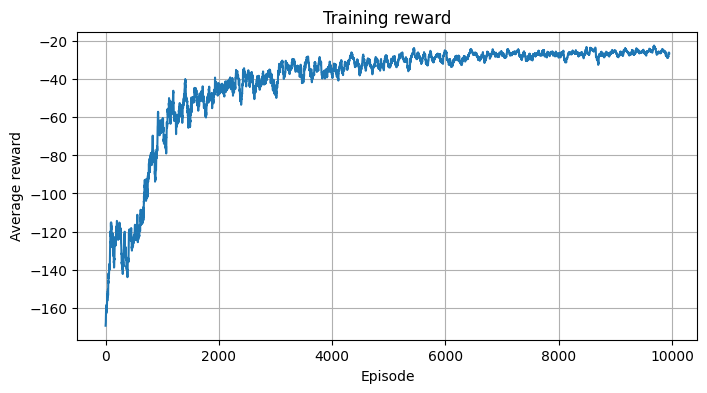

Test steps: 100
Final distance: 0.1689980453124467


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# =========================
# 1. Simple 2-link planar arm
# =========================
L1 = 1.0
L2 = 1.0

def forward_kinematics(theta1, theta2):
    x1 = L1 * np.cos(theta1)
    y1 = L1 * np.sin(theta1)

    x2 = x1 + L2 * np.cos(theta1 + theta2)
    y2 = y1 + L2 * np.sin(theta1 + theta2)
    return x1, y1, x2, y2

# =========================
# 2. Target point
# =========================
target = np.array([1.2, 0.8])

# =========================
# 3. Discretized state space
# =========================
n_bins1 = 21
n_bins2 = 21

theta1_vals = np.linspace(-np.pi, np.pi, n_bins1)
theta2_vals = np.linspace(-np.pi, np.pi, n_bins2)

def angle_to_index(theta, angle_grid):
    # wrap angle to [-pi, pi]
    theta = (theta + np.pi) % (2 * np.pi) - np.pi
    return np.argmin(np.abs(angle_grid - theta))

def state_to_angles(s1, s2):
    return theta1_vals[s1], theta2_vals[s2]

# =========================
# 4. Actions
# =========================
# Each action changes joint angles by one grid step
actions = [
    (-1, 0),   # theta1 down
    ( 1, 0),   # theta1 up
    ( 0,-1),   # theta2 down
    ( 0, 1),   # theta2 up
    (-1,-1),   # both down
    (-1, 1),   # theta1 down, theta2 up
    ( 1,-1),   # theta1up, theta2 down
    ( 1, 1),   # both up
]
n_actions = len(actions)

# =========================
# 5. Q-table
# =========================
Q = np.zeros((n_bins1, n_bins2, n_actions))

# =========================
# 6. Environment step
# =========================
def env_step(s1, s2, action_id):
    a1, a2 = actions[action_id]

    ns1 = np.clip(s1 + a1, 0, n_bins1 - 1)
    ns2 = np.clip(s2 + a2, 0, n_bins2 - 1)

    theta1, theta2 = state_to_angles(ns1, ns2)
    _, _, xe, ye = forward_kinematics(theta1, theta2)

    ee = np.array([xe, ye])
    dist = np.linalg.norm(ee - target)

    # reward: encourage getting close to target
    reward = -dist

    done = dist < 0.10
    if done:
        reward += 10.0

    return ns1, ns2, reward, done, dist

# =========================
# 7. Training with Q-learning
# =========================
alpha = 0.15
gamma = 0.95
epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.995

episodes = 10000
max_steps = 100

reward_history = []
success_history = []

for ep in range(episodes):
    s1 = np.random.randint(0, n_bins1)
    s2 = np.random.randint(0, n_bins2)

    total_reward = 0
    success = 0

    for step in range(max_steps):
        if np.random.rand() < epsilon:
            action_id = np.random.randint(n_actions)
        else:
            action_id = np.argmax(Q[s1, s2])

        ns1, ns2, reward, done, dist = env_step(s1, s2, action_id)

        Q[s1, s2, action_id] = Q[s1, s2, action_id] + alpha * (
            reward + gamma * np.max(Q[ns1, ns2]) - Q[s1, s2, action_id]
        )

        s1, s2 = ns1, ns2
        total_reward += reward

        if done:
            success = 1
            break

    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    reward_history.append(total_reward)
    success_history.append(success)

print("Training finished.")
print("Final epsilon =", epsilon)
print("Success rate over last 100 episodes =", np.mean(success_history[-100:]))

# =========================
# 8. Plot training curve
# =========================
window = 50
avg_rewards = np.convolve(reward_history, np.ones(window)/window, mode='valid')
avg_success = np.convolve(success_history, np.ones(window)/window, mode='valid')

plt.figure(figsize=(8,4))
plt.plot(avg_rewards)
plt.xlabel("Episode")
plt.ylabel("Average reward")
plt.title("Training reward")
plt.grid(True)
plt.show()


# =========================
# 9. Test learned policy
# =========================
s1 = np.random.randint(0, n_bins1)
s2 = np.random.randint(0, n_bins2)

trajectory = []

for step in range(max_steps):
    theta1, theta2 = state_to_angles(s1, s2)
    x1, y1, x2, y2 = forward_kinematics(theta1, theta2)
    dist = np.linalg.norm(np.array([x2, y2]) - target)

    trajectory.append((x1, y1, x2, y2, dist))

    if dist < 0.10:
        break

    action_id = np.argmax(Q[s1, s2])
    s1, s2, _, _, _ = env_step(s1, s2, action_id)

print("Test steps:", len(trajectory))
print("Final distance:", trajectory[-1][4])

# =========================
# 10. Visualize final trajectory
# =========================
fig, ax = plt.subplots(figsize=(6,6))
ax.set_xlim(-2.2, 2.2)
ax.set_ylim(-2.2, 2.2)
ax.set_aspect('equal')
ax.grid(True)
ax.set_title("2-link planar arm RL")

target_plot, = ax.plot(target[0], target[1], 'rx', markersize=12, label='Target')
link1_plot, = ax.plot([], [], 'o-', linewidth=4)
link2_plot, = ax.plot([], [], 'o-', linewidth=4)
path_plot, = ax.plot([], [], '--', linewidth=1)

ee_path_x = []
ee_path_y = []

def init():
    link1_plot.set_data([], [])
    link2_plot.set_data([], [])
    path_plot.set_data([], [])
    return link1_plot, link2_plot, path_plot

def update(frame):
    x1, y1, x2, y2, dist = trajectory[frame]

    link1_plot.set_data([0, x1], [0, y1])
    link2_plot.set_data([x1, x2], [y1, y2])

    ee_path_x.append(x2)
    ee_path_y.append(y2)
    path_plot.set_data(ee_path_x, ee_path_y)

    ax.set_title(f"2-link planar arm RL | step={frame} | dist={dist:.3f}")
    return link1_plot, link2_plot, path_plot

ani = FuncAnimation(fig, update, frames=len(trajectory), init_func=init,
                    interval=300, blit=True)

plt.legend()
plt.close(fig)
HTML(ani.to_jshtml())